# #18 · Pre-launch regression models for US and Canada

@yeekitc · due Friday 2026-09-25 · [issue #18](https://github.com/Break-Through-Tech/Estee-Lauder-1B-measuring-customer-delight/issues/18)

**Canada is already the control** (`eda_final` §4–5) — this is not a selection exercise.
It asks one question: were the two markets on the same trend before launch?

**Answer: no measurable difference.** US +0.0032/week, Canada +0.0022/week, difference
+0.0010/week with a 95% CI of [−0.0006, +0.0026] that straddles zero.

That is a failure to detect, not proof of none. Modelling seasonality matters a lot here:
on a bare straight line the evidence couldn't rule out a pre-existing drift worth ±1.4× the
DiD estimate; with month effects that narrows to +0.55/−0.13×.

In [1]:
import sys
sys.path.append("../../src")

import matplotlib.pyplot as plt
import pandas as pd

import simple_did as sd

df = sd.load_panel()
CONTROL = "Canada"

## 1. A straight line is a bad model here

`eda_final` §2 found real seasonality — March–May is the US high. A line can't represent
it, so that movement lands in the residual and swamps the trend. Month effects fix it.

In [2]:
rows = []
for market in [sd.PILOT, CONTROL]:
    for seasonal, label in [(False, "trend only"), (True, "trend + month")]:
        fit = sd.fit_market_model(df, market, seasonal=seasonal)
        rows.append({"market": market, "model": label,
                     "slope_per_week": fit.params["week_index"],
                     "adj_r2": fit.rsquared_adj})

pd.DataFrame(rows).round(5)

,market,model,slope_per_week,adj_r2
0,United States,trend only,0.00272,0.04094
1,United States,trend + month,0.00356,0.65127
2,Canada,trend only,0.00174,0.01380
3,Canada,trend + month,0.00181,0.66854


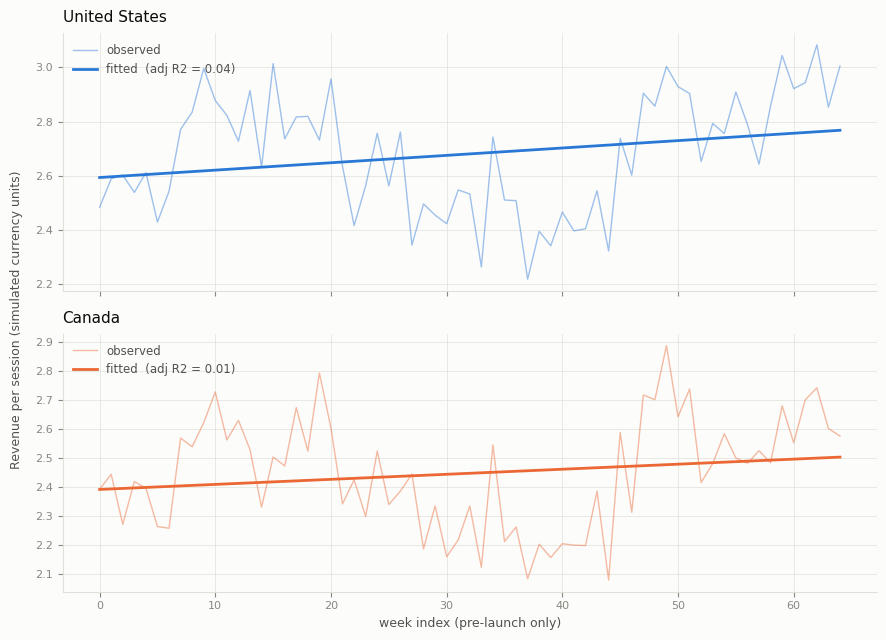

In [3]:
fig = sd.plot_model_fit(df, control=CONTROL, seasonal=False)
fig.savefig("../../figures/simple_did/prelaunch_model_fit_linear.png", dpi=200, bbox_inches="tight")
plt.show()

The line cuts straight through the seasonal swings — that is the 0.04 / 0.01 above,
made visual. Month effects are what make the trend comparison legible.

## Slide 1 — the same model fits both markets

Each market is fitted **independently**, so the shared seasonal shape is a finding, not
something the model imposed. Look for it: the dips and peaks land in the same weeks.

Fit quality only here — slopes come from the pooled model on slide 2, and mixing the two
would put numbers on this chart that don't subtract to the difference reported below.

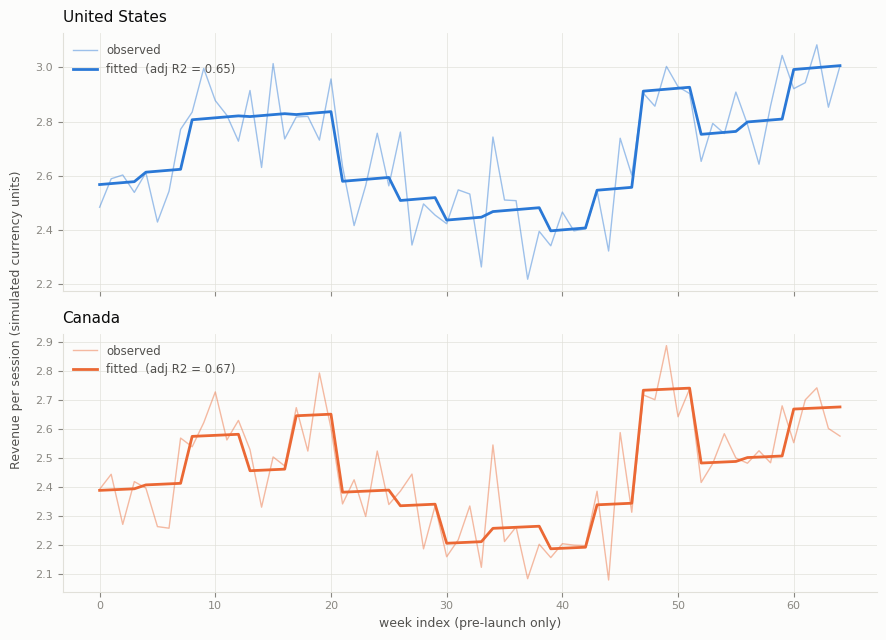

In [4]:
fig = sd.plot_model_fit(df, control=CONTROL)
fig.savefig("../../figures/simple_did/prelaunch_model_fit.png", dpi=200, bbox_inches="tight")
plt.show()

## Slide 2 — the trends are not measurably different

One pooled model, `revenue_per_session ~ week_index * is_treated + C(month)`, so the three
rows reconcile: Canada is `week_index`, the US is `week_index + interaction`, the
difference is the interaction. Newey–West standard errors, since weekly revenue is
serially correlated.

  US slope      +0.003178 / week
  Canada slope  +0.002197 / week
  difference    +0.000981 / week
  95% CI        [-0.000624, +0.002587]   p = 0.231


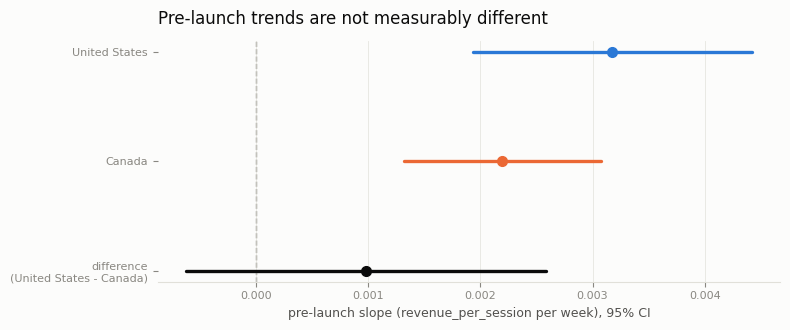

In [5]:
res = sd.pre_trend_test(df, control=CONTROL)
print(f"  US slope      {res['treated_slope']:+.6f} / week")
print(f"  Canada slope  {res['control_slope']:+.6f} / week")
print(f"  difference    {res['slope_diff']:+.6f} / week")
print(f"  95% CI        [{res['ci_low']:+.6f}, {res['ci_high']:+.6f}]   p = {res['p_value']:.3f}")

fig = sd.plot_slope_comparison(df, control=CONTROL)
fig.savefig("../../figures/simple_did/prelaunch_slope_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## The caveat for #22 and #24

A slope gap compounds into the DiD through the 52 weeks between the mean pre and mean post
week, so what the test *fails* to exclude still matters.

In [6]:
b = sd.pre_trend_bias_bound(df, control=CONTROL)
print(f"  ATT {b['att']:+.4f}   pre-trend drift could account for "
      f"{b['ci_low_share_of_att']*100:+.0f}% to {b['ci_high_share_of_att']*100:+.0f}% of it")

  ATT +0.2459   pre-trend drift could account for -13% to +55% of it


> Pre-launch trends are not measurably different, and Canada tracks the US more closely
> than 73% of market pairs in this panel. But 65 weeks still admits a pre-existing drift
> worth up to about half the estimated effect — report the ATT with that range attached.

**For Milestone #4:** reuse `sd.pre_trend_test` / `sd.plot_slope_comparison`; its docstring
records why p-values here are indicative only and which specifications to avoid on two
markets.

_TODO @yeekitc: wording check before this goes in the deck._